# (a) Data Generation

In [1]:
import numpy as np
rng = np.random.default_rng(42)
X = rng.random(size=(1000, 20))
beta_vec = np.hstack((rng.random(size=13)*100, np.zeros(7)))
eps = rng.normal(size = 1000)
Y = np.dot(X, beta_vec) + eps # Or, Y = X @ beta_vec + eps 

In [2]:
Y

array([395.01724927, 348.97443313, 340.25030134, 311.70809882,
       274.90212455, 346.5179827 , 292.21767814, 347.05323061,
       349.99797372, 395.96959822, 319.06323968, 316.90027376,
       440.84758119, 214.00349563, 221.16257851, 305.00425283,
       417.11436359, 388.79822177, 331.67016795, 389.37885379,
       387.06725122, 328.50501856, 341.05510838, 306.0899891 ,
       283.71729091, 409.54681067, 427.13806344, 315.84847891,
       304.68394317, 317.32411849, 462.89968843, 416.71338574,
       416.99116584, 388.10957781, 333.10319712, 378.44897941,
       193.8956325 , 226.98453384, 234.18319433, 394.6132395 ,
       255.80481503, 343.60972624, 275.74347124, 370.00040973,
       289.71684624, 359.20967729, 301.0463144 , 372.86031191,
       297.98787671, 394.7634559 , 343.95147935, 459.29928557,
       285.91995862, 384.04877001, 434.38797341, 275.03633193,
       336.69612967, 390.65687204, 359.36975224, 299.15057518,
       334.67301958, 286.65787764, 276.69175362, 337.26

# (b) Splitting the generated data into training and test sets

In [3]:
X_train, Y_train = X[:100], Y[:100]
X_test, Y_test = X[100:], Y[100:]

# (c) & (d) Best subset selection 

In [4]:
# Slower Version using the scikit learn. It takes few minutes to run

# import itertools
# from sklearn.linear_model import LinearRegression
# from sklearn import metrics
# best_train_mses = []

# for r in range(1, 21):
#     best_mse = float('inf')

#     # Loop through all the combinations of size r
#     combinations = itertools.combinations(range(20), r)
#     for c in combinations:
#         X_train_selected = X_train[:, c]
#         model = LinearRegression()
#         model.fit(X_train_selected, Y_train)
#         training_mse = metrics.mean_squared_error(Y_train, model.predict(X_train_selected))
#         best_mse = min(best_mse, training_mse)
#     best_train_mses.append(best_mse)
    

In [45]:
# Faster Version using the numpy linalg module
import itertools
best_train_mses = []
best_test_mses = []
best_beta_hat_coeffs = []
for r in range(1, 21):
    best_mse = float('inf')
    best_cols = None
    best_beta_hat = None
    for c in itertools.combinations(range(20), r):
        X_train_selected = X_train[:, c]
        # Fast least squares solver using numpy
        beta_hat, _, _, _ = np.linalg.lstsq(X_train_selected, Y_train, rcond=None)

        # Training MSE
        train_pred = X_train_selected @ beta_hat
        training_mse = np.mean((Y_train - train_pred) ** 2)

        if training_mse < best_mse:
            best_mse = training_mse
            best_cols = c
            best_beta_hat = np.zeros(20)
            best_beta_hat[list(c)] = beta_hat

    best_beta_hat_coeffs.append(best_beta_hat)
    
    best_train_mses.append(best_mse)
    
    test_pred = X_test @ best_beta_hat
    test_mse = np.mean((Y_test - test_pred) ** 2)
    best_test_mses.append(test_mse)

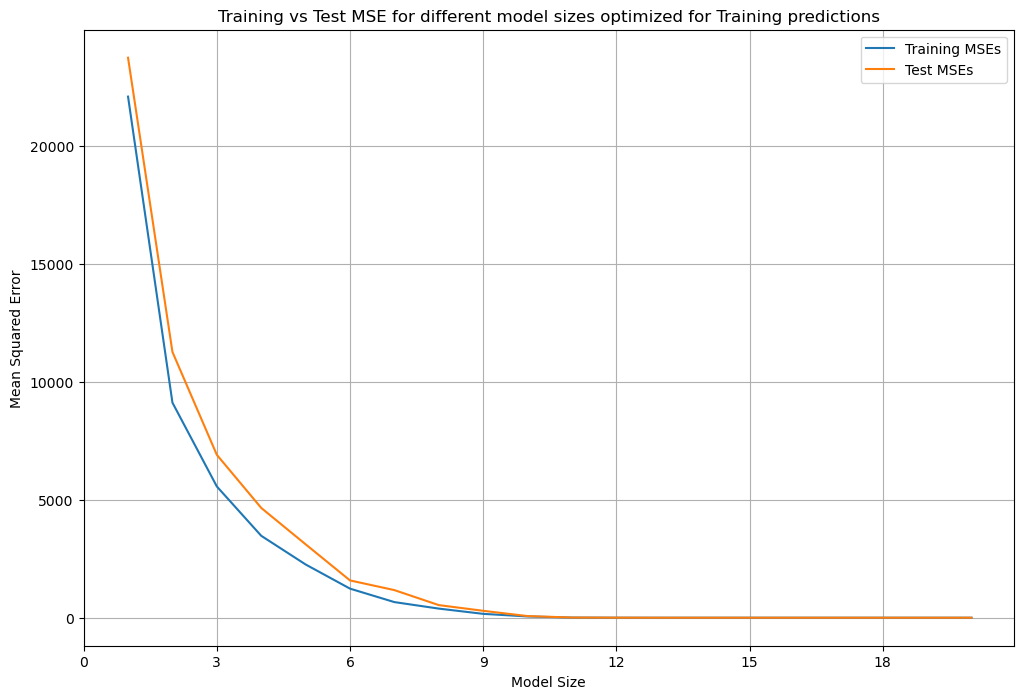

In [27]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(range(1, 21), best_train_mses, label="Training MSEs")
ax.plot(range(1, 21), best_test_mses, label="Test MSEs")
ax.legend()
ax.grid(True)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Model Size")
ax.set_title("Training vs Test MSE for different model sizes optimized for Training predictions")
ax.set_xticks(range(0, 21, 3));

# (e)

In [32]:
np.argmin(best_test_mses) + 1

np.int64(13)

# (f)

In [35]:
best_beta_hat_coeffs[12]

array([ 73.54403081, 100.38908954,   3.61002554,  24.8329913 ,
        59.60797997,  41.41653955,  64.09651538,  58.28786504,
        79.27228796,   7.08319856,  44.26274515,  85.88800402,
        36.02664524])

In [36]:
beta_vec

array([74.07727546, 99.58064657,  4.09773088, 24.49194347, 59.77407484,
       41.51944533, 63.75562065, 58.64043331, 78.79894679,  7.09029201,
       44.06160699, 86.00537897, 36.27619053,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [38]:
import pandas as pd
pd.DataFrame({'Actual Coeff': beta_vec[:13], 'Best Model Coeff': best_beta_hat_coeffs[12]})

,Actual Coeff,Best Model Coeff
0,74.077275,73.544031
1,99.580647,100.389090
2,4.097731,3.610026
3,24.491943,24.832991
4,59.774075,59.607980
5,41.519445,41.416540
6,63.755621,64.096515
7,58.640433,58.287865
8,78.798947,79.272288
9,7.090292,7.083199


# (g)

In [55]:
scores = [np.sqrt(np.sum(np.square(beta_vec - b))) for b in best_beta_hat_coeffs]
scores

[np.float64(477.2119531687168),
 np.float64(336.3535818235213),
 np.float64(267.735432430358),
 np.float64(230.51742528584887),
 np.float64(182.9400404226521),
 np.float64(133.2522789871465),
 np.float64(116.18143519633655),
 np.float64(81.63687132144679),
 np.float64(59.4852517054819),
 np.float64(28.959246743698372),
 np.float64(9.33843911714265),
 np.float64(4.875748152686467),
 np.float64(1.3825336163031687),
 np.float64(1.392869236595293),
 np.float64(1.4358813880372254),
 np.float64(1.4424651241736013),
 np.float64(1.4366903642295699),
 np.float64(1.4573827328377076),
 np.float64(1.4503889962544523),
 np.float64(1.4472032954493563)]

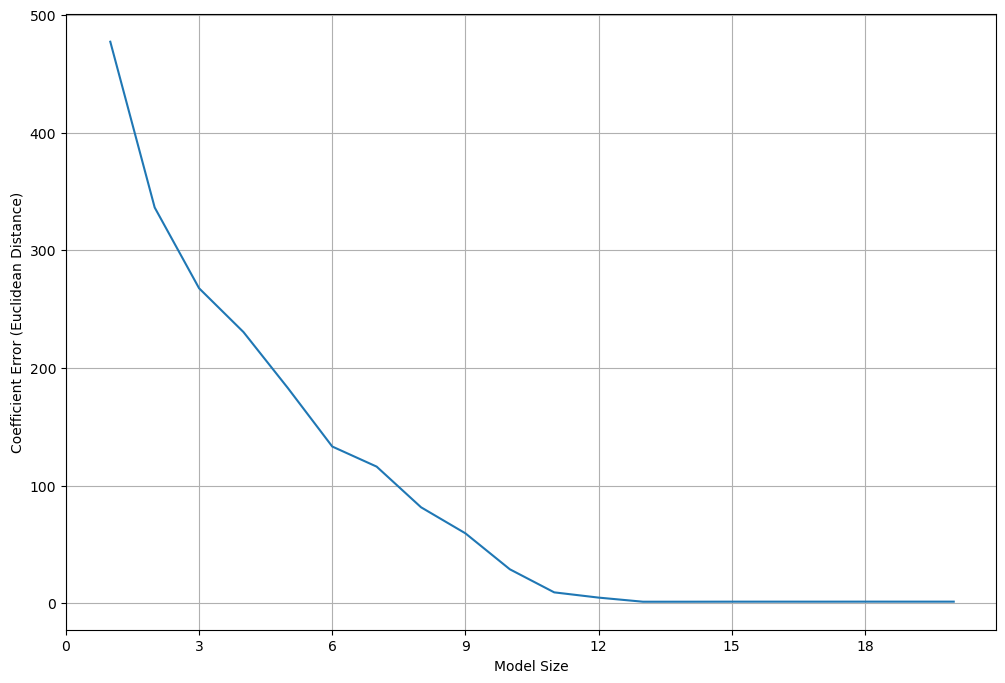

In [59]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(range(1, 21), scores)
ax.grid(True)
ax.set_ylabel("Coefficient Error (Euclidean Distance)")
ax.set_xlabel("Model Size")
ax.set_xticks(range(0, 21, 3));